In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import wfdb


from utils.CAM import CAM_ResNet
from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# ResNet CAM analysis

In [2]:
config_path = "../configs/resnet_full.yaml"

In [3]:
config = load_config(config_path)
config["experiment"]["device"] = "cpu"
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

# dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
# _, val_loader_f, test_loader_f = dataset_f.get_loaders()

# dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
# _, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [4]:
trainer = build_trainer(config)
trainer.load_checkpoint()

In [5]:
cam = CAM_ResNet(trainer.model)

In [6]:
df = dataset.test_ds.frame
df_mi = df[df['has_mi']==1]
df_healthy = df[df['has_mi']==0]

df_mi_f = df_mi[df_mi['sex']==1]
df_mi_m = df_mi[df_mi['sex']==0]
df_healthy_f = df_healthy[df_healthy['sex']==1]
df_healthy_m = df_healthy[df_healthy['sex']==0]

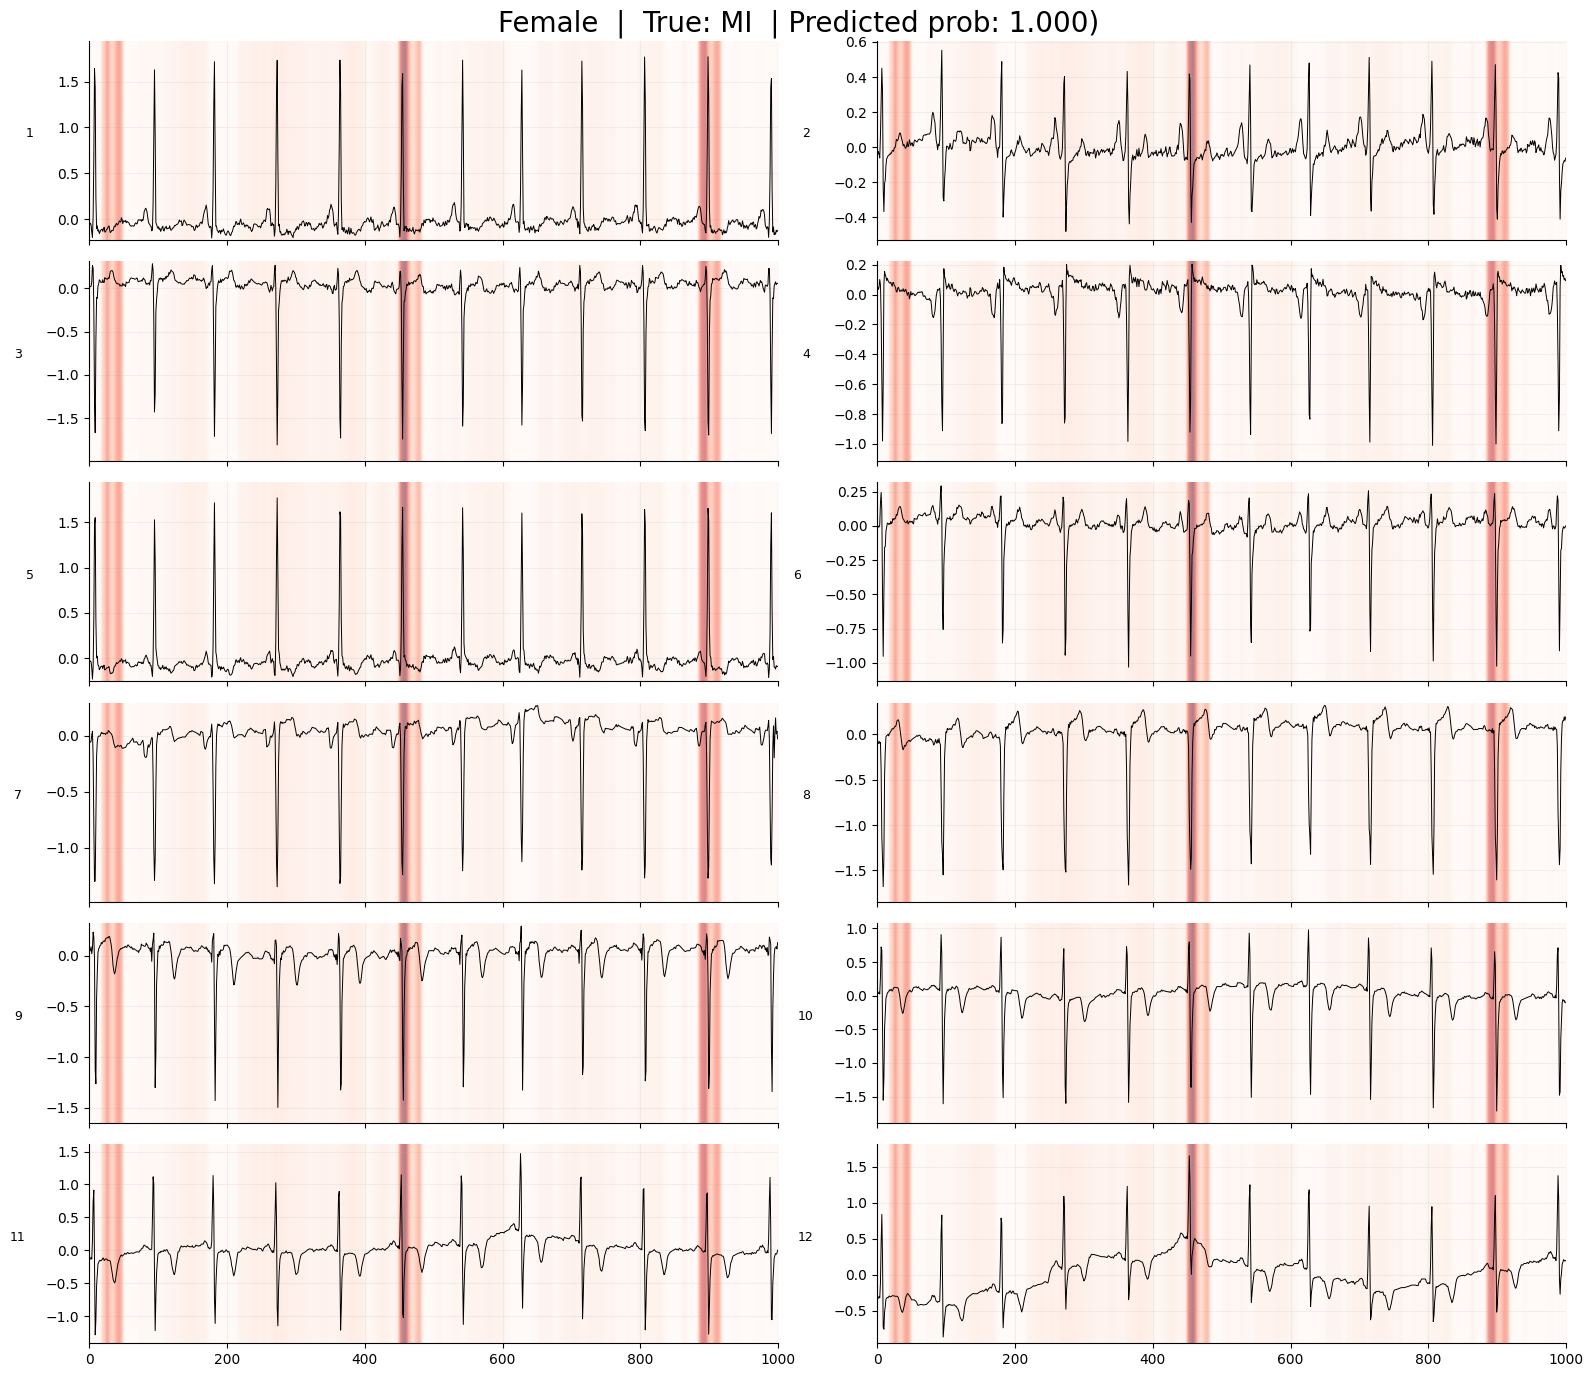

In [8]:
cam.plot_cam_12leads(dataset.test_ds, df_mi_f.index[1])

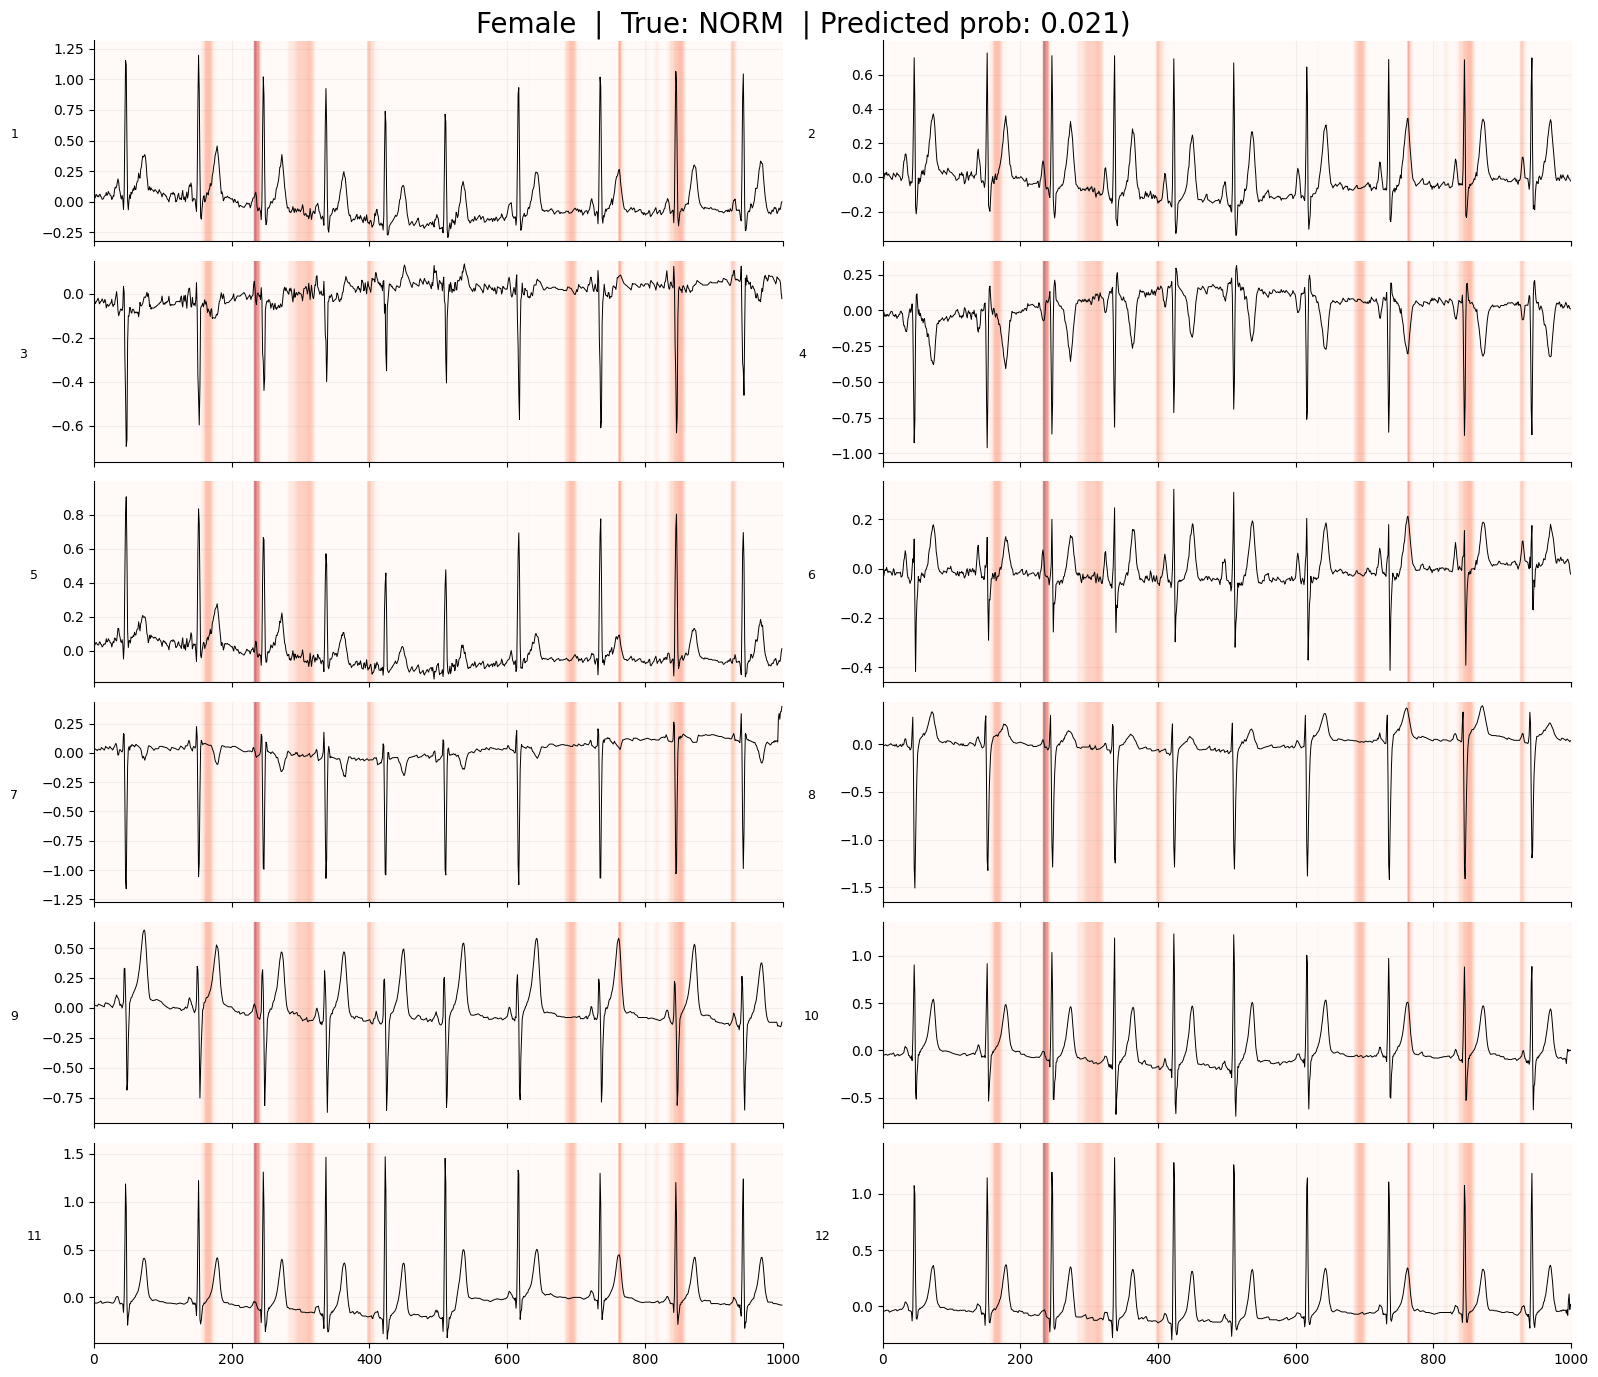

In [8]:
cam.plot_cam_12leads(dataset.test_ds, df_healthy_f.index[0])

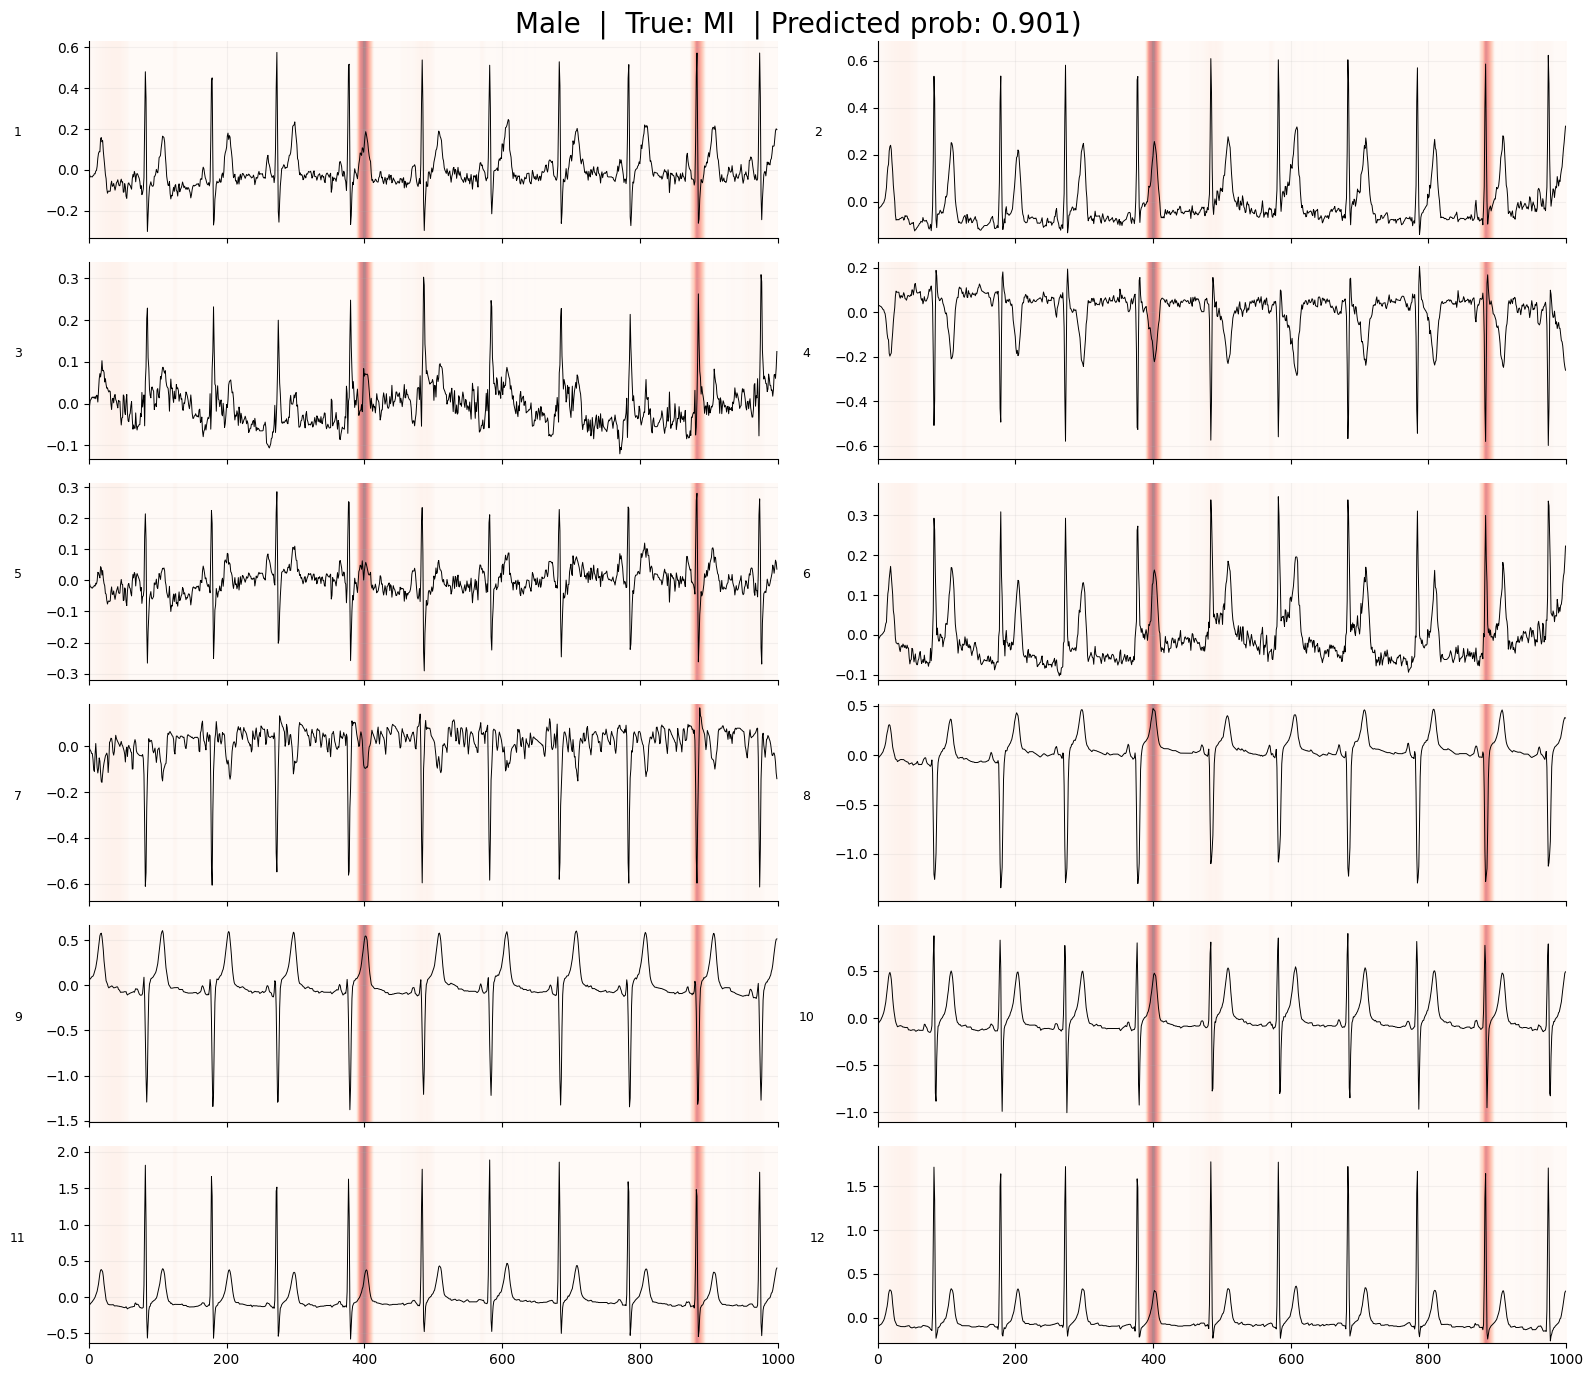

In [9]:
cam.plot_cam_12leads(dataset.test_ds, df_mi_m.index[0])

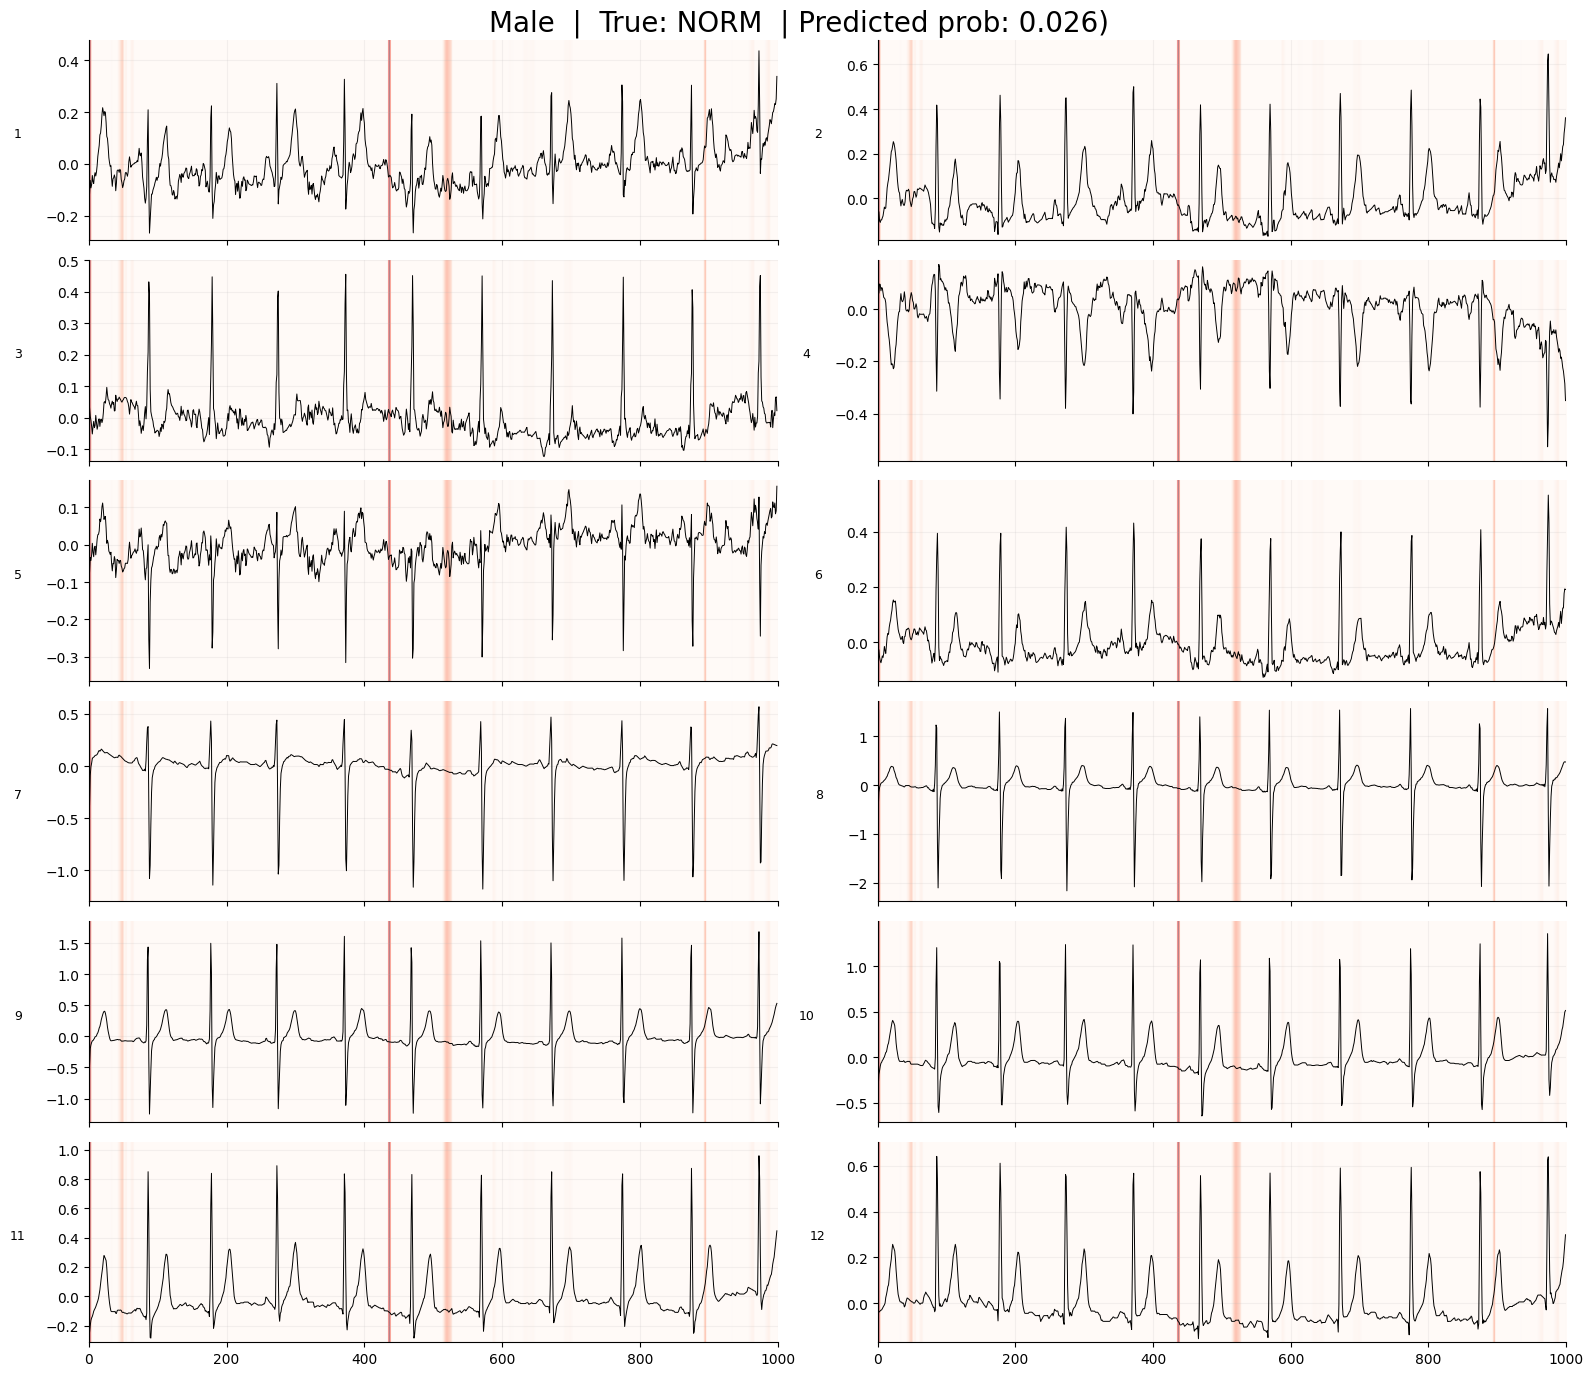

In [10]:
cam.plot_cam_12leads(dataset.test_ds, df_healthy_m.index[0])